In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("merged_dataset.csv")

print(df.shape)
print(df.head())
print(df.columns)

(1747, 46)
  participant_id        date  fatigue  mood  readiness  stress  \
0            p01  2019-11-01        2     3          5       3   
1            p01  2019-11-02        2     3          6       3   
2            p01  2019-11-03        3     3          8       3   
3            p01  2019-11-04        3     3          8       3   
4            p01  2019-11-05        3     3          8       3   

   sleep_duration_h  sleep_quality  sleep_minutes_asleep  sleep_minutes_awake  \
0                 6              3                   NaN                  NaN   
1                 6              3                 378.0                 52.0   
2                 6              3                 378.0                 44.0   
3                 6              3                 361.0                 38.0   
4                 5              3                 326.0                 36.0   

   ...  active_very_min  sedentary_min  exercise_count  exercise_duration_min  \
0  ...               72 

In [10]:
# A1 - Entropy

from math import log2

target = "high_fatigue"

def entropy(data):
    values = data.value_counts()
    total = len(data)

    result = 0

    for count in values:
        p = count / total
        result = result - p * log2(p)

    return result

print("Entropy =", entropy(df[target]))

Entropy = 0.38009625130181773


In [11]:
# A2 - Gini Index

def gini(data):
    values = data.value_counts()
    total = len(data)
    
    result = 1
    
    for count in values:
        p = count / total
        result = result - p * p
    
    return result

print("Gini Index =", gini(df[target]))

Gini Index = 0.13677679194261885


In [14]:
#A3.
import math

target = "high_fatigue"

def entropy(data):
    counts = data.value_counts()
    total = len(data)
    
    h = 0
    for count in counts:
        p = count / total
        h -= p * math.log2(p)
    
    return h


def information_gain(data, feature, target):
    parent_entropy = entropy(data[target])
    
    weighted_entropy = 0
    
    for value in data[feature].unique():
        subset = data[data[feature] == value]
        
        weighted_entropy += (
            len(subset) / len(data)
        ) * entropy(subset[target])
    
    return parent_entropy - weighted_entropy

features = df.select_dtypes(include="number").columns.tolist()

if target in features:
    features.remove(target)

features = features[:5]

for feature in features:
    df[feature + "_bin"] = pd.cut(
        df[feature],
        bins=4,
        labels=False
    )

    gain = information_gain(
        df,
        feature + "_bin",
        target
    )

    print(feature, " Information Gain ", round(gain, 4))

fatigue  Information Gain  0.3801
mood  Information Gain  0.0359
readiness  Information Gain  0.0595
stress  Information Gain  0.0222
sleep_duration_h  Information Gain  0.0266


In [15]:
#A4.
import pandas as pd

feature = df.select_dtypes(include="number").columns[0]

binned = pd.cut(df[feature], bins=4, labels=False)

print("Feature:", feature)
print("Original:")
print(df[feature].head())

print("\nAfter Equal Width Binning:")
print(binned.head())

Feature: fatigue
Original:
0    2
1    2
2    3
3    3
4    3
Name: fatigue, dtype: int64

After Equal Width Binning:
0    1
1    1
2    2
3    2
4    2
Name: fatigue, dtype: int64


In [ ]:
# A5: Own Decision Tree

class Node:
    def __init__(self, feature=None, branches=None, prediction=None):
        self.feature = feature
        self.branches = branches
        self.prediction = prediction


def build_tree(data, features, target, depth=0, max_depth=3):
    if data[target].nunique() == 1:
        return Node(prediction=data[target].iloc[0])

    if depth >= max_depth or len(features) == 0:
        return Node(prediction=data[target].mode()[0])

    gains = {}

    for feature in features:
        gains[feature] = information_gain(data, feature, target)

    best_feature = max(gains, key=gains.get)

    node = Node(feature=best_feature, branches={})
    for value in data[best_feature].dropna().unique():

        subset = data[data[best_feature] == value]

        if len(subset) == 0:
            continue

        remaining_features = [
            f for f in features if f != best_feature
        ]

        node.branches[value] = build_tree(
            subset,
            remaining_features,
            target,
            depth + 1,
            max_depth
        )

    return node


# Get binned features created in A3
binned_features = [
    c for c in df.columns if c.endswith("_bin")
]

# Build the tree
tree = build_tree(
    df,
    binned_features,
    target,
    max_depth=3
)

print("Decision Tree successfully created!")
print("Root Node:", tree.feature)

Decision Tree successfully created!
Root Node: fatigue_bin


In [18]:
def print_tree(node, level=0):

    if node.prediction is not None:
        print("  " * level + "Predict:", node.prediction)
        return

    print("  " * level + "Feature:", node.feature)

    for value, child in node.branches.items():
        print("  " * level + "If", value)
        print_tree(child, level + 1)


print_tree(tree)

Feature: fatigue_bin
If 1
  Predict: 0
If 2
  Predict: 0
If 3
  Predict: 1
If 0
  Predict: 0


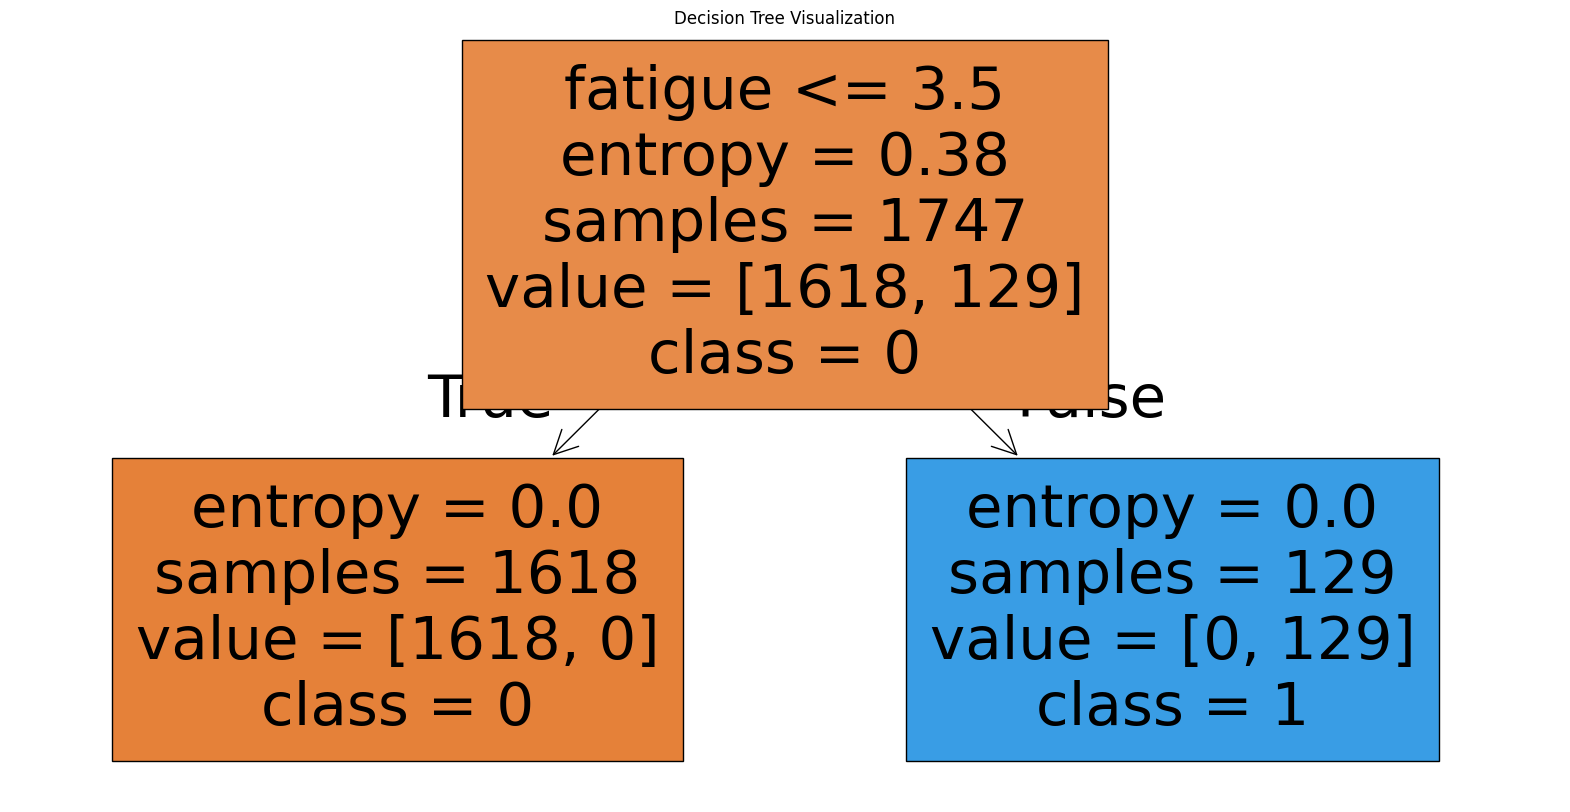

In [21]:
#A6.
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
features = df.select_dtypes(include="number").columns.tolist()

if target in features:
    features.remove(target)

X = df[features].fillna(df[features].median())
y = df[target]

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

model.fit(X, y)
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=features,
    class_names=[str(c) for c in model.classes_],
    filled=True
)
plt.title("Decision Tree Visualization")
plt.show()

Feature 1: fatigue
Feature 2: mood


C:\Users\saian\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


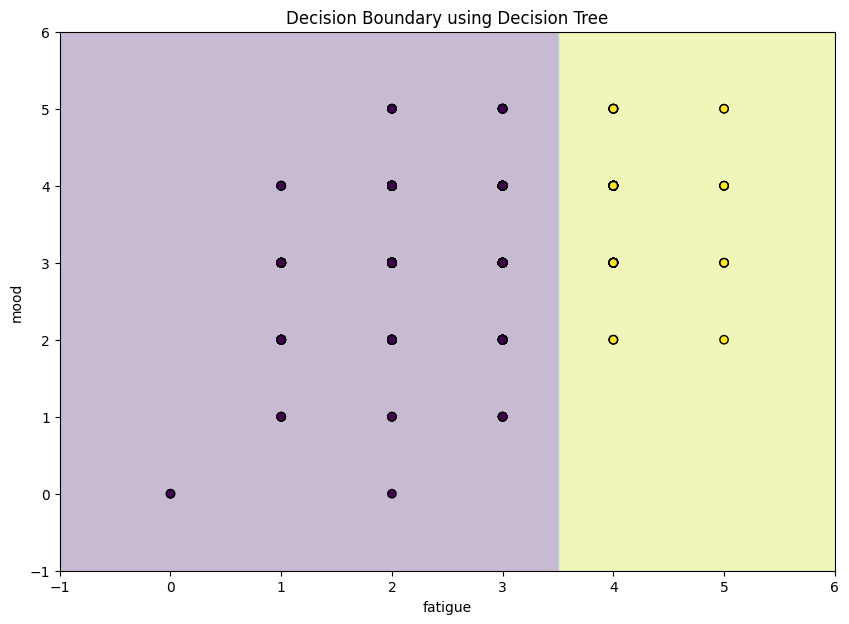

In [19]:
#A7.
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np
import matplotlib.pyplot as plt
features = df.select_dtypes(include="number").columns.tolist()

if target in features:
    features.remove(target)

feature1 = features[0]
feature2 = features[1]

print("Feature 1:", feature1)
print("Feature 2:", feature2)

X = df[[feature1, feature2]].fillna(
    df[[feature1, feature2]].median()
)

le = LabelEncoder()
y = le.fit_transform(df[target])

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

model.fit(X, y)
x_min, x_max = X[feature1].min() - 1, X[feature1].max() + 1
y_min, y_max = X[feature2].min() - 1, X[feature2].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

plt.scatter(
    X[feature1],
    X[feature2],
    c=y,
    edgecolors="black"
)

plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title("Decision Boundary using Decision Tree")
plt.show()

In [20]:
#A8.
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

features = df.select_dtypes(include="number").columns.tolist()

if target in features:
    features.remove(target)

X = df[features].fillna(df[features].median())
y = df[target]

model = DecisionTreeClassifier(random_state=42)

parameters = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, 6],
    "min_samples_split": [2, 5, 10]
}
grid = GridSearchCV(
    model,
    parameters,
    cv=5,
    scoring="accuracy"
)

grid.fit(X, y)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Accuracy:")
print(grid.best_score_)

Best Parameters:
{'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2}

Best Accuracy:
1.0
